# Projeto 2 - Ciência de Dados
# Nome: Thales Kun Sales
# Matrícula: 2410100485
# Professor: Sandro Camargo <sandrocamargo@unipampa.edu.br>
# Aula 05 - Classificação

## Adaptação: Predict Students' Dropout and Academic Success (UCI)

Notebook adaptado a partir do exemplo do Titanic, agora aplicado ao dataset de evasão/sucesso acadêmico, com classificação **multiclasse** (Evasão, Matriculado, Formado).

Dicionário oficial das variáveis: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

# 📦 PACOTES


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, classification_report

# 📥 CARREGAR DADOS

O arquivo `data.csv` usa `;` como separador (padrão europeu). Coloque-o na mesma pasta do notebook (ou faça upload no Colab).

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/ThalesKun/classificacao-academic-success/refs/heads/main/data.csv", sep=";")

# remove espaços/tabs perdidos nos nomes das colunas
df.columns = [c.strip() for c in df.columns]

# ---- Renomeia as colunas para português (facilita a apresentação) ----
colunas_pt = {
    "Marital status": "Estado civil",
    "Application mode": "Modo de candidatura",
    "Application order": "Ordem de candidatura",
    "Course": "Curso",
    "Daytime/evening attendance": "Turno",
    "Previous qualification": "Qualificação anterior",
    "Previous qualification (grade)": "Qualificação anterior (nota)",
    "Nacionality": "Nacionalidade",
    "Mother's qualification": "Qualificação da mãe",
    "Father's qualification": "Qualificação do pai",
    "Mother's occupation": "Ocupação da mãe",
    "Father's occupation": "Ocupação do pai",
    "Admission grade": "Nota de admissão",
    "Displaced": "Deslocado",
    "Educational special needs": "Necessidades educativas especiais",
    "Debtor": "Devedor",
    "Tuition fees up to date": "Mensalidades em dia",
    "Gender": "Gênero",
    "Scholarship holder": "Bolsista",
    "Age at enrollment": "Idade na matrícula",
    "International": "Internacional",
    "Curricular units 1st sem (credited)": "Disciplinas 1º sem (creditadas)",
    "Curricular units 1st sem (enrolled)": "Disciplinas 1º sem (matriculadas)",
    "Curricular units 1st sem (evaluations)": "Disciplinas 1º sem (avaliações)",
    "Curricular units 1st sem (approved)": "Disciplinas 1º sem (aprovadas)",
    "Curricular units 1st sem (grade)": "Disciplinas 1º sem (nota)",
    "Curricular units 1st sem (without evaluations)": "Disciplinas 1º sem (sem avaliação)",
    "Curricular units 2nd sem (credited)": "Disciplinas 2º sem (creditadas)",
    "Curricular units 2nd sem (enrolled)": "Disciplinas 2º sem (matriculadas)",
    "Curricular units 2nd sem (evaluations)": "Disciplinas 2º sem (avaliações)",
    "Curricular units 2nd sem (approved)": "Disciplinas 2º sem (aprovadas)",
    "Curricular units 2nd sem (grade)": "Disciplinas 2º sem (nota)",
    "Curricular units 2nd sem (without evaluations)": "Disciplinas 2º sem (sem avaliação)",
    "Unemployment rate": "Taxa de desemprego",
    "Inflation rate": "Taxa de inflação",
    "GDP": "PIB",
    "Target": "Situação",
}
df = df.rename(columns=colunas_pt)

df.head()


,Estado civil,Modo de candidatura,Ordem de candidatura,Curso,Turno,Qualificação anterior,Qualificação anterior (nota),Nacionalidade,Qualificação da mãe,Qualificação do pai,...,Disciplinas 2º sem (creditadas),Disciplinas 2º sem (matriculadas),Disciplinas 2º sem (avaliações),Disciplinas 2º sem (aprovadas),Disciplinas 2º sem (nota),Disciplinas 2º sem (sem avaliação),Taxa de desemprego,Taxa de inflação,PIB,Situação
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# 🏷️ DECODIFICAÇÃO DAS VARIÁVEIS CATEGÓRICAS

No site da UCI, cada variável categórica vem como número, mas o número representa uma categoria (ex.: `Estado civil = 1` significa "Solteiro(a)"). Isso **não afeta o desempenho do modelo**, porque já usamos `OneHotEncoder` nessas colunas — ele trata cada valor como uma categoria nominal, sem assumir nenhuma ordem ou escala entre os códigos (1, 2, 3... não significam "mais" ou "menos" nada).

O ganho de decodificar é **interpretabilidade**: os gráficos, a árvore de decisão e a importância das variáveis ficam legíveis ("Curso_Enfermagem" em vez de "Curso_9500"). Por isso, mapeamos para texto as colunas em que a UCI documenta o significado de cada código.

Duas colunas (`Ocupação da mãe` e `Ocupação do pai`) **não decodificamos**: seguem uma classificação ocupacional portuguesa (CPP/ISCO) com dezenas de códigos que não estão listados de forma completa na página da UCI, e mapear errado seria pior do que não mapear. Deixamos como código numérico-categórico mesmo (o `OneHotEncoder` continua tratando corretamente como categoria).

In [ ]:
estado_civil_map = {
    1: "Solteiro(a)", 2: "Casado(a)", 3: "Viúvo(a)", 4: "Divorciado(a)",
    5: "União estável", 6: "Separado(a) judicialmente"
}

modo_candidatura_map = {
    1: "1ª fase - contingente geral", 2: "Portaria 612/93",
    5: "1ª fase - contingente especial (Açores)", 7: "Titulares de outros cursos superiores",
    10: "Portaria 854-B/99", 15: "Estudante internacional (bacharelado)",
    16: "1ª fase - contingente especial (Madeira)", 17: "2ª fase - contingente geral",
    18: "3ª fase - contingente geral", 26: "Portaria 533-A/99, item b2",
    27: "Portaria 533-A/99, item b3", 39: "Maiores de 23 anos", 42: "Transferência",
    43: "Mudança de curso", 44: "Diploma de especialização tecnológica",
    51: "Mudança de instituição/curso", 53: "Titulares de diploma de ciclo curto",
    57: "Mudança de instituição/curso (Internacional)"
}

curso_map = {
    33: "Tecnologias de Produção de Biocombustíveis", 171: "Animação e Design Multimídia",
    8014: "Serviço Social (noturno)", 9003: "Agronomia", 9070: "Design de Comunicação",
    9085: "Enfermagem Veterinária", 9119: "Engenharia Informática", 9130: "Equinocultura",
    9147: "Gestão", 9238: "Serviço Social", 9254: "Turismo", 9500: "Enfermagem",
    9556: "Higiene Oral", 9670: "Gestão de Publicidade e Marketing",
    9773: "Jornalismo e Comunicação", 9853: "Educação Básica",
    9991: "Gestão (noturno)"
}

turno_map = {1: "Diurno", 0: "Noturno"}

qualificacao_map = {
    1: "Ensino secundário", 2: "Ensino superior - bacharelado", 3: "Ensino superior - licenciatura",
    4: "Ensino superior - mestrado", 5: "Ensino superior - doutorado", 6: "Frequência de ensino superior",
    9: "12º ano - não concluído", 10: "11º ano - não concluído",
    11: "7º ano (antigo)", 12: "Outro - 11º ano", 13: "2º ano do ensino médio complementar",
    14: "10º ano de escolaridade", 15: "10º ano - não concluído",
    18: "Curso geral de comércio", 19: "Ensino básico 3º ciclo (9º/10º/11º ano)",
    20: "Ensino médio complementar", 22: "Curso técnico-profissional",
    25: "Ensino médio complementar - não concluído", 26: "7º ano de escolaridade",
    27: "2º ciclo do ensino médio geral", 29: "9º ano - não concluído",
    30: "8º ano de escolaridade", 31: "Curso geral de Administração e Comércio",
    33: "Contabilidade e Administração (suplementar)", 34: "Desconhecido",
    35: "Não sabe ler ou escrever", 36: "Sabe ler, sem 4º ano",
    37: "Ensino básico 1º ciclo (4º/5º ano)", 38: "Ensino básico 2º ciclo (6º/7º/8º ano)",
    39: "Curso de especialização tecnológica", 40: "Ensino superior - licenciatura (1º ciclo)",
    41: "Curso de estudos superiores especializados", 42: "Curso técnico superior profissional",
    43: "Ensino superior - mestrado (2º ciclo)", 44: "Ensino superior - doutorado (3º ciclo)"
}

nacionalidade_map = {
    1: "Português", 2: "Alemão", 6: "Espanhol", 11: "Italiano", 13: "Holandês",
    14: "Inglês", 17: "Lituano", 21: "Angolano", 22: "Cabo-verdiano",
    24: "Guineense", 25: "Moçambicano", 26: "São-tomense", 32: "Turco",
    41: "Brasileiro", 62: "Romeno", 100: "Moldávio", 101: "Mexicano",
    103: "Ucraniano", 105: "Russo", 108: "Cubano", 109: "Colombiano"
}

binarias_map = {0: "Não", 1: "Sim"}
genero_map = {0: "Feminino", 1: "Masculino"}
situacao_map = {"Dropout": "Evasão", "Enrolled": "Matriculado", "Graduate": "Formado"}

# aplica os mapeamentos (mantém o código original quando não há correspondência)
df["Estado civil"] = df["Estado civil"].map(estado_civil_map).fillna(df["Estado civil"])
df["Modo de candidatura"] = df["Modo de candidatura"].map(modo_candidatura_map).fillna(df["Modo de candidatura"])
df["Curso"] = df["Curso"].map(curso_map).fillna(df["Curso"])
df["Turno"] = df["Turno"].map(turno_map)
df["Qualificação anterior"] = df["Qualificação anterior"].map(qualificacao_map).fillna(df["Qualificação anterior"])
df["Nacionalidade"] = df["Nacionalidade"].map(nacionalidade_map).fillna(df["Nacionalidade"])
df["Qualificação da mãe"] = df["Qualificação da mãe"].map(qualificacao_map).fillna(df["Qualificação da mãe"])
df["Qualificação do pai"] = df["Qualificação do pai"].map(qualificacao_map).fillna(df["Qualificação do pai"])

for col in ["Deslocado", "Necessidades educativas especiais", "Devedor", "Mensalidades em dia",
            "Bolsista", "Internacional"]:
    df[col] = df[col].map(binarias_map)

df["Gênero"] = df["Gênero"].map(genero_map)

# traduz a variável-alvo (Situação): Dropout/Enrolled/Graduate -> Evasão/Matriculado/Formado
df["Situação"] = df["Situação"].map(situacao_map).fillna(df["Situação"])

# Ocupação da mãe / Ocupação do pai: mantidas como código (ver explicação acima)

df.head()


,Estado civil,Modo de candidatura,Ordem de candidatura,Curso,Turno,Qualificação anterior,Qualificação anterior (nota),Nacionalidade,Qualificação da mãe,Qualificação do pai,...,Disciplinas 2º sem (creditadas),Disciplinas 2º sem (matriculadas),Disciplinas 2º sem (avaliações),Disciplinas 2º sem (aprovadas),Disciplinas 2º sem (nota),Disciplinas 2º sem (sem avaliação),Taxa de desemprego,Taxa de inflação,PIB,Situação
0,Solteiro(a),2ª fase - contingente geral,5,Animação e Design Multimídia,Diurno,Ensino secundário,122.0,Português,Ensino básico 3º ciclo (9º/10º/11º ano),Outro - 11º ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Evasão
1,Solteiro(a),Estudante internacional (bacharelado),1,Turismo,Diurno,Ensino secundário,160.0,Português,Ensino secundário,Ensino superior - licenciatura,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Formado
2,Solteiro(a),1ª fase - contingente geral,5,Design de Comunicação,Diurno,Ensino secundário,122.0,Português,Ensino básico 1º ciclo (4º/5º ano),Ensino básico 1º ciclo (4º/5º ano),...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Evasão
3,Solteiro(a),2ª fase - contingente geral,2,Jornalismo e Comunicação,Diurno,Ensino secundário,122.0,Português,Ensino básico 2º ciclo (6º/7º/8º ano),Ensino básico 1º ciclo (4º/5º ano),...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Formado
4,Casado(a),Maiores de 23 anos,1,Serviço Social (noturno),Noturno,Ensino secundário,100.0,Português,Ensino básico 1º ciclo (4º/5º ano),Ensino básico 2º ciclo (6º/7º/8º ano),...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Formado


# 🎯 VARIÁVEL ALVO

Diferente do Titanic (binário: sobreviveu/não), aqui a `Situação` tem 3 classes: `Evasão`, `Matriculado`, `Formado`.

In [ ]:
y = df["Situação"]
X = df.drop(columns=["Situação"])

y.value_counts()


,count
Situação,
Formado,2209
Evasão,1421
Matriculado,794


# 🔧 FEATURES

Separação entre numéricas (notas, contagens, indicadores macroeconômicos) e categóricas. Agora tanto os **nomes das colunas** quanto os **valores** dentro delas estão em português (onde foi possível decodificar), o que deixa a apresentação e os gráficos bem mais legíveis.

In [ ]:
num_features = [
    "Qualificação anterior (nota)",
    "Nota de admissão",
    "Idade na matrícula",
    "Disciplinas 1º sem (creditadas)",
    "Disciplinas 1º sem (matriculadas)",
    "Disciplinas 1º sem (avaliações)",
    "Disciplinas 1º sem (aprovadas)",
    "Disciplinas 1º sem (nota)",
    "Disciplinas 1º sem (sem avaliação)",
    "Disciplinas 2º sem (creditadas)",
    "Disciplinas 2º sem (matriculadas)",
    "Disciplinas 2º sem (avaliações)",
    "Disciplinas 2º sem (aprovadas)",
    "Disciplinas 2º sem (nota)",
    "Disciplinas 2º sem (sem avaliação)",
    "Taxa de desemprego",
    "Taxa de inflação",
    "PIB",
]

cat_features = [
    "Estado civil",
    "Modo de candidatura",
    "Ordem de candidatura",
    "Curso",
    "Turno",
    "Qualificação anterior",
    "Nacionalidade",
    "Qualificação da mãe",
    "Qualificação do pai",
    "Ocupação da mãe",
    "Ocupação do pai",
    "Deslocado",
    "Necessidades educativas especiais",
    "Devedor",
    "Mensalidades em dia",
    "Gênero",
    "Bolsista",
    "Internacional",
]


# 🔄 PIPELINE DE PRÉ-PROCESSAMENTO


In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

# ✂️ SPLIT


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🤖 MODELOS


In [ ]:
modelos = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=11),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=500, random_state=42)
}

# 🚀 TREINAMENTO E AVALIAÇÃO


In [ ]:
resultados = {}

for nome, modelo in modelos.items():

    pipeline = Pipeline([
        ("preprocessamento", preprocessor),
        ("modelo", modelo)
    ])

    # treino
    pipeline.fit(X_train, y_train)

    # predição
    y_pred = pipeline.predict(X_test)

    # métricas
    acc = accuracy_score(y_test, y_pred)

    resultados[nome] = acc

    print(f"\n📊 {nome}")
    print(f"Acurácia: {acc:.4f}")
    print(classification_report(y_test, y_pred))


📊 Decision Tree
Acurácia: 0.6972
              precision    recall  f1-score   support

      Evasão       0.69      0.68      0.68       284
     Formado       0.80      0.81      0.80       442
 Matriculado       0.42      0.40      0.41       159

    accuracy                           0.70       885
   macro avg       0.63      0.63      0.63       885
weighted avg       0.69      0.70      0.70       885


📊 Random Forest
Acurácia: 0.7718
              precision    recall  f1-score   support

      Evasão       0.82      0.77      0.80       284
     Formado       0.78      0.95      0.86       442
 Matriculado       0.54      0.27      0.36       159

    accuracy                           0.77       885
   macro avg       0.72      0.67      0.67       885
weighted avg       0.75      0.77      0.75       885


📊 KNN
Acurácia: 0.7141
              precision    recall  f1-score   support

      Evasão       0.80      0.64      0.71       284
     Formado       0.71      0.96    

In [ ]:
# ===============================
# 🏆 COMPARAÇÃO FINAL
# ===============================
print("\n🏆 Comparação de modelos:")
for nome, acc in resultados.items():
    print(f"{nome}: {acc:.4f}")


🏆 Comparação de modelos:
Decision Tree: 0.6972
Random Forest: 0.7718
KNN: 0.7141
Neural Network: 0.7175


# Mostrando modelo de Decision Tree


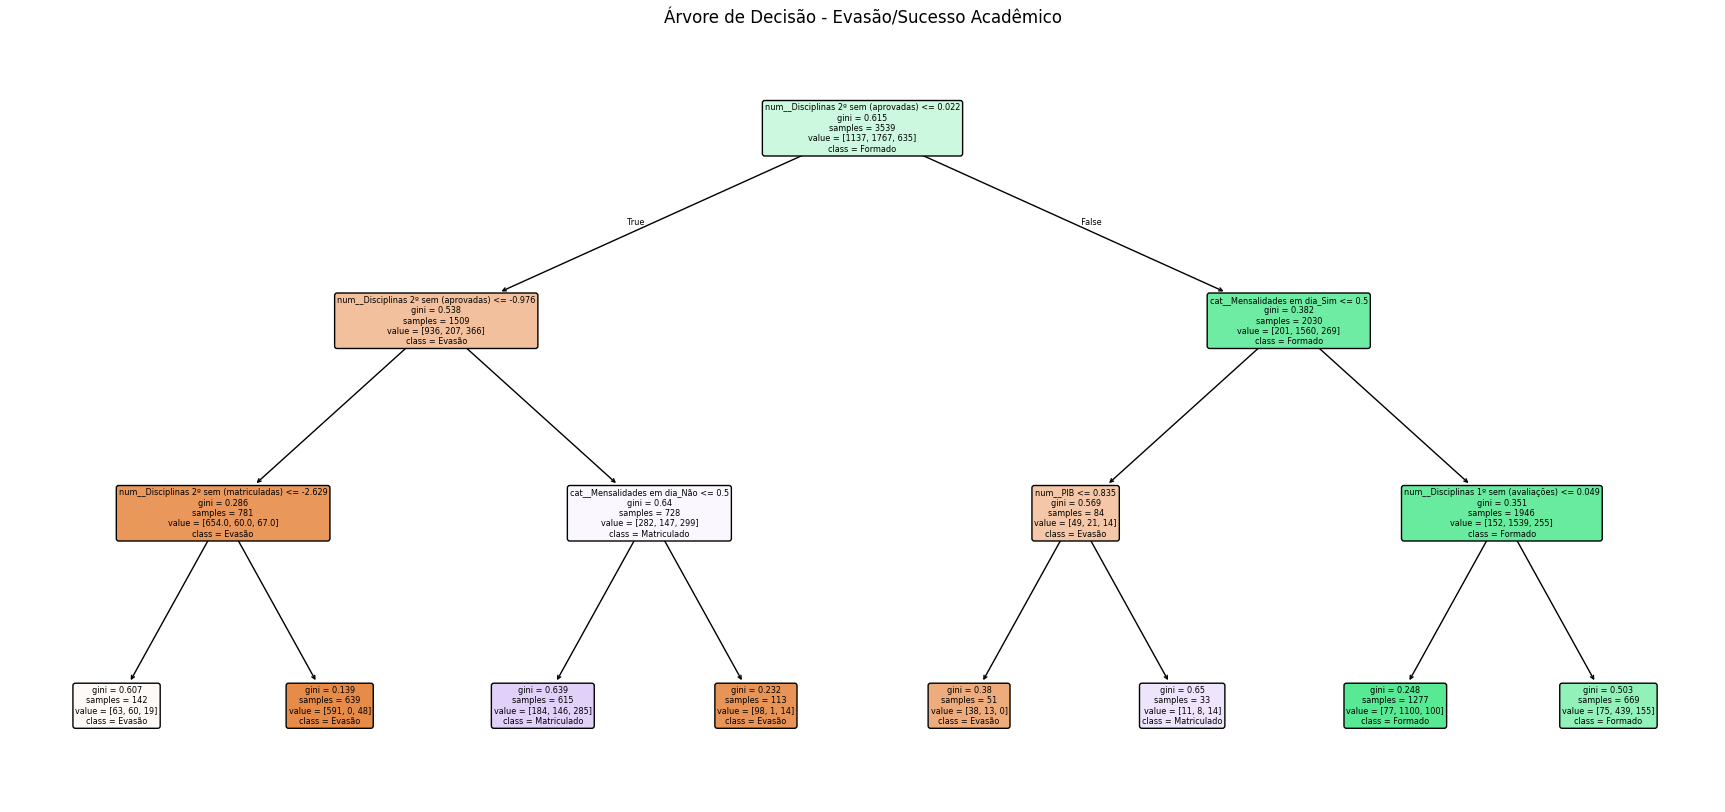

IF num__Disciplinas 2º sem (aprovadas) <= 0.02 AND num__Disciplinas 2º sem (aprovadas) <= -0.98 AND num__Disciplinas 2º sem (matriculadas) <= -2.63 THEN class = Evasão
IF num__Disciplinas 2º sem (aprovadas) <= 0.02 AND num__Disciplinas 2º sem (aprovadas) <= -0.98 AND num__Disciplinas 2º sem (matriculadas) > -2.63 THEN class = Evasão
IF num__Disciplinas 2º sem (aprovadas) <= 0.02 AND num__Disciplinas 2º sem (aprovadas) > -0.98 AND cat__Mensalidades em dia_Não <= 0.50 THEN class = Matriculado
IF num__Disciplinas 2º sem (aprovadas) <= 0.02 AND num__Disciplinas 2º sem (aprovadas) > -0.98 AND cat__Mensalidades em dia_Não > 0.50 THEN class = Evasão
IF num__Disciplinas 2º sem (aprovadas) > 0.02 AND cat__Mensalidades em dia_Sim <= 0.50 AND num__PIB <= 0.83 THEN class = Evasão
IF num__Disciplinas 2º sem (aprovadas) > 0.02 AND cat__Mensalidades em dia_Sim <= 0.50 AND num__PIB > 0.83 THEN class = Matriculado
IF num__Disciplinas 2º sem (aprovadas) > 0.02 AND cat__Mensalidades em dia_Sim > 0.50 AND

In [ ]:
pipeline = Pipeline([
    ("preprocessamento", preprocessor),
    ("modelo", DecisionTreeClassifier(random_state=42, max_depth=3))
])

pipeline.fit(X_train, y_train)

arvore = pipeline.named_steps["modelo"]

feature_names = pipeline.named_steps["preprocessamento"].get_feature_names_out()
class_names = [str(c) for c in arvore.classes_]

# mostrar a árvore
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22,10))

plot_tree(
    arvore,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True
)

plt.title("Árvore de Decisão - Evasão/Sucesso Acadêmico")
plt.show()


# mostrar regras
def extrair_regras(arvore, feature_names, class_names):
    from sklearn.tree import _tree

    tree_ = arvore.tree_
    features = feature_names

    def recurse(node, regra):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = features[tree_.feature[node]]
            threshold = tree_.threshold[node]

            # esquerda
            recurse(tree_.children_left[node],
                    regra + [f"{name} <= {threshold:.2f}"])

            # direita
            recurse(tree_.children_right[node],
                    regra + [f"{name} > {threshold:.2f}"])
        else:
            classe = class_names[np.argmax(tree_.value[node])]
            print("IF " + " AND ".join(regra) + f" THEN class = {classe}")

    recurse(0, [])

# executar
extrair_regras(arvore, feature_names, class_names)

# Visualizando os dados de acordo com a decision tree


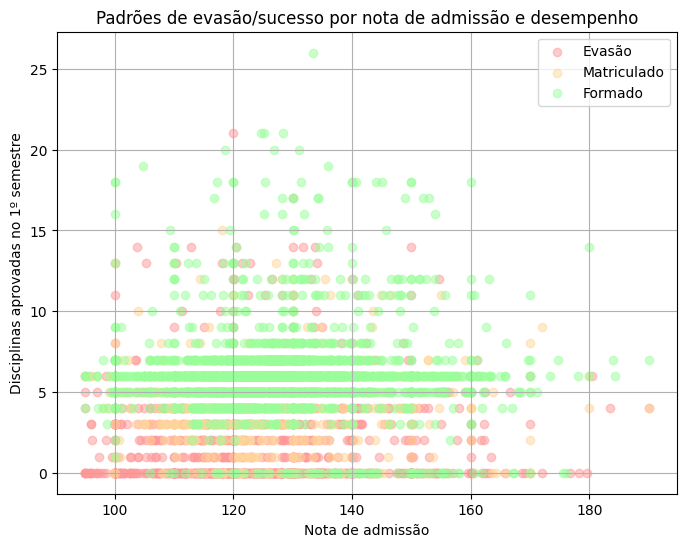

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cores = {"Evasão": "#ff9999", "Matriculado": "#ffd699", "Formado": "#99ff99"}

plt.figure(figsize=(8,6))

for classe, cor in cores.items():
    mask = y == classe
    plt.scatter(
        X["Nota de admissão"][mask],
        X["Disciplinas 1º sem (aprovadas)"][mask],
        color=cor,
        alpha=0.5,
        label=classe
    )

plt.xlabel("Nota de admissão")
plt.ylabel("Disciplinas aprovadas no 1º semestre")
plt.title("Padrões de evasão/sucesso por nota de admissão e desempenho")

plt.legend()
plt.grid(True)

plt.show()


# Random Forest


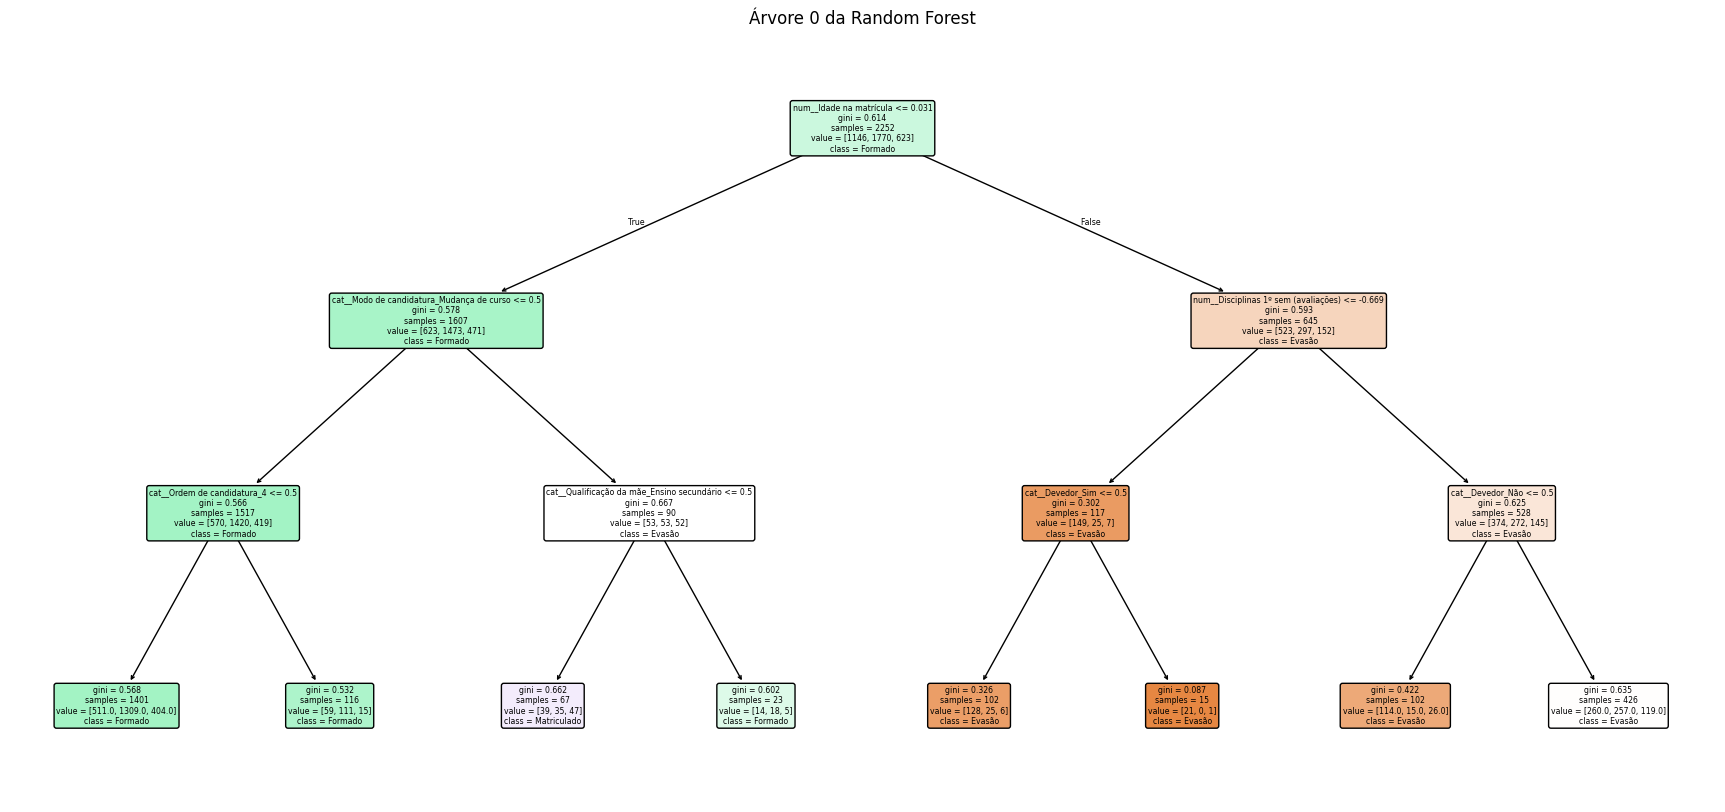

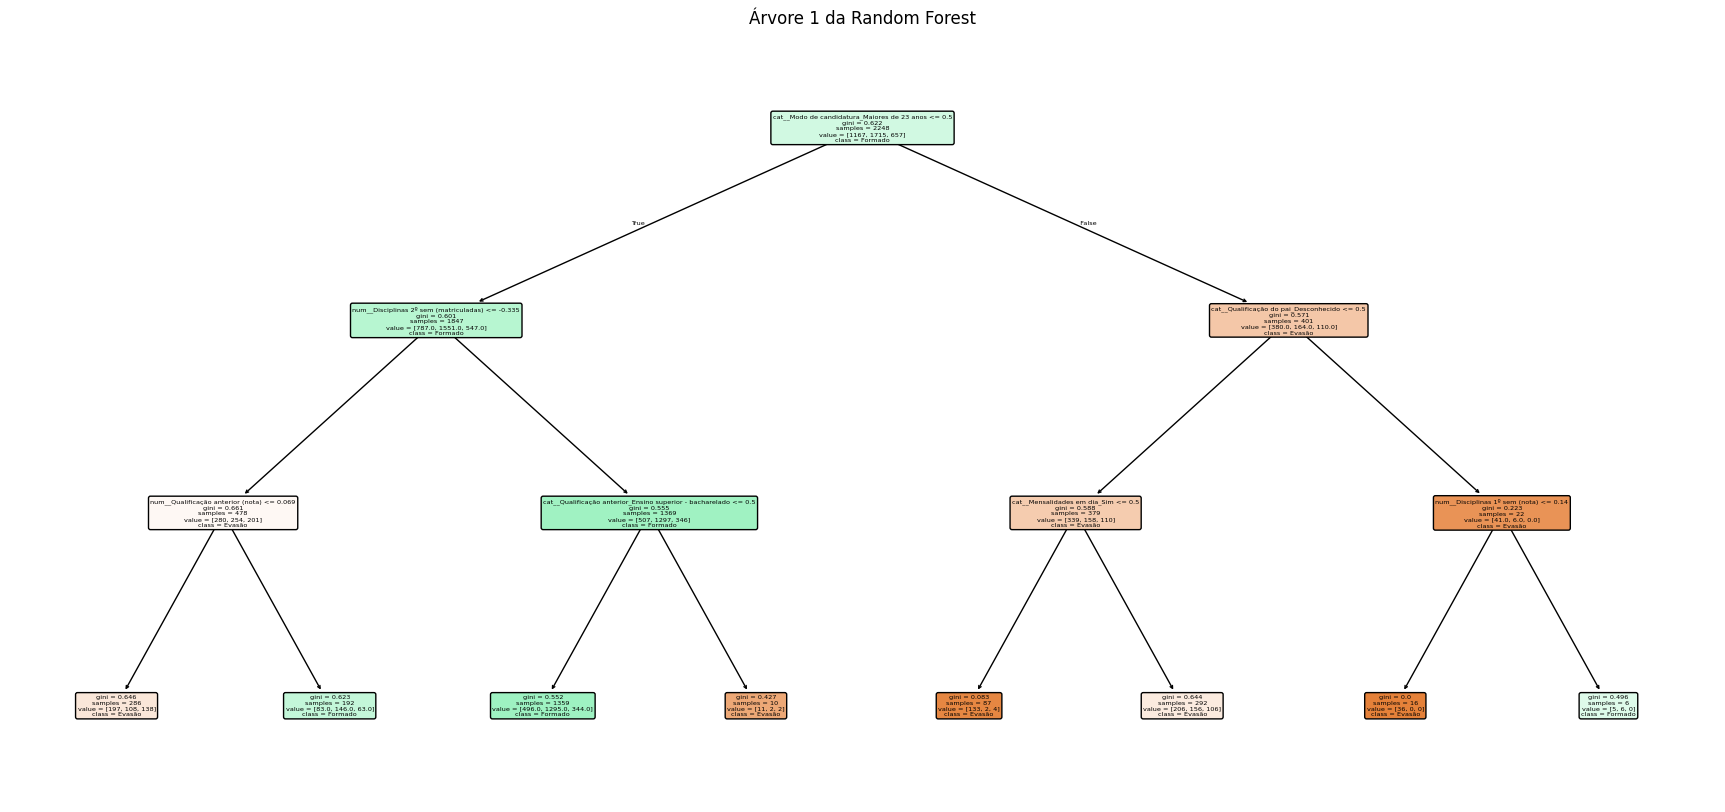

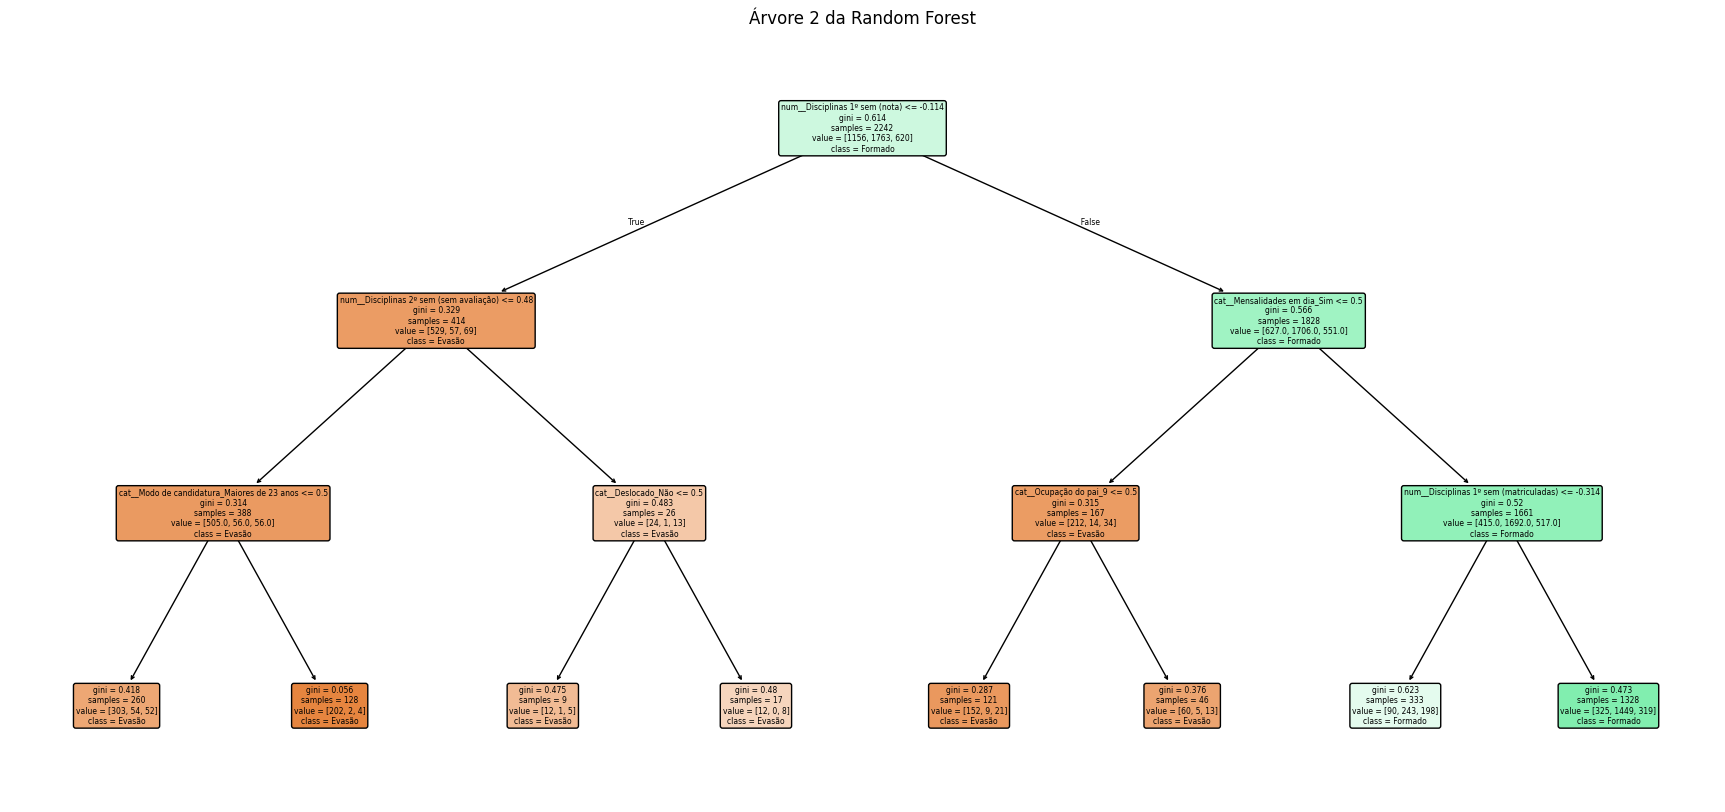

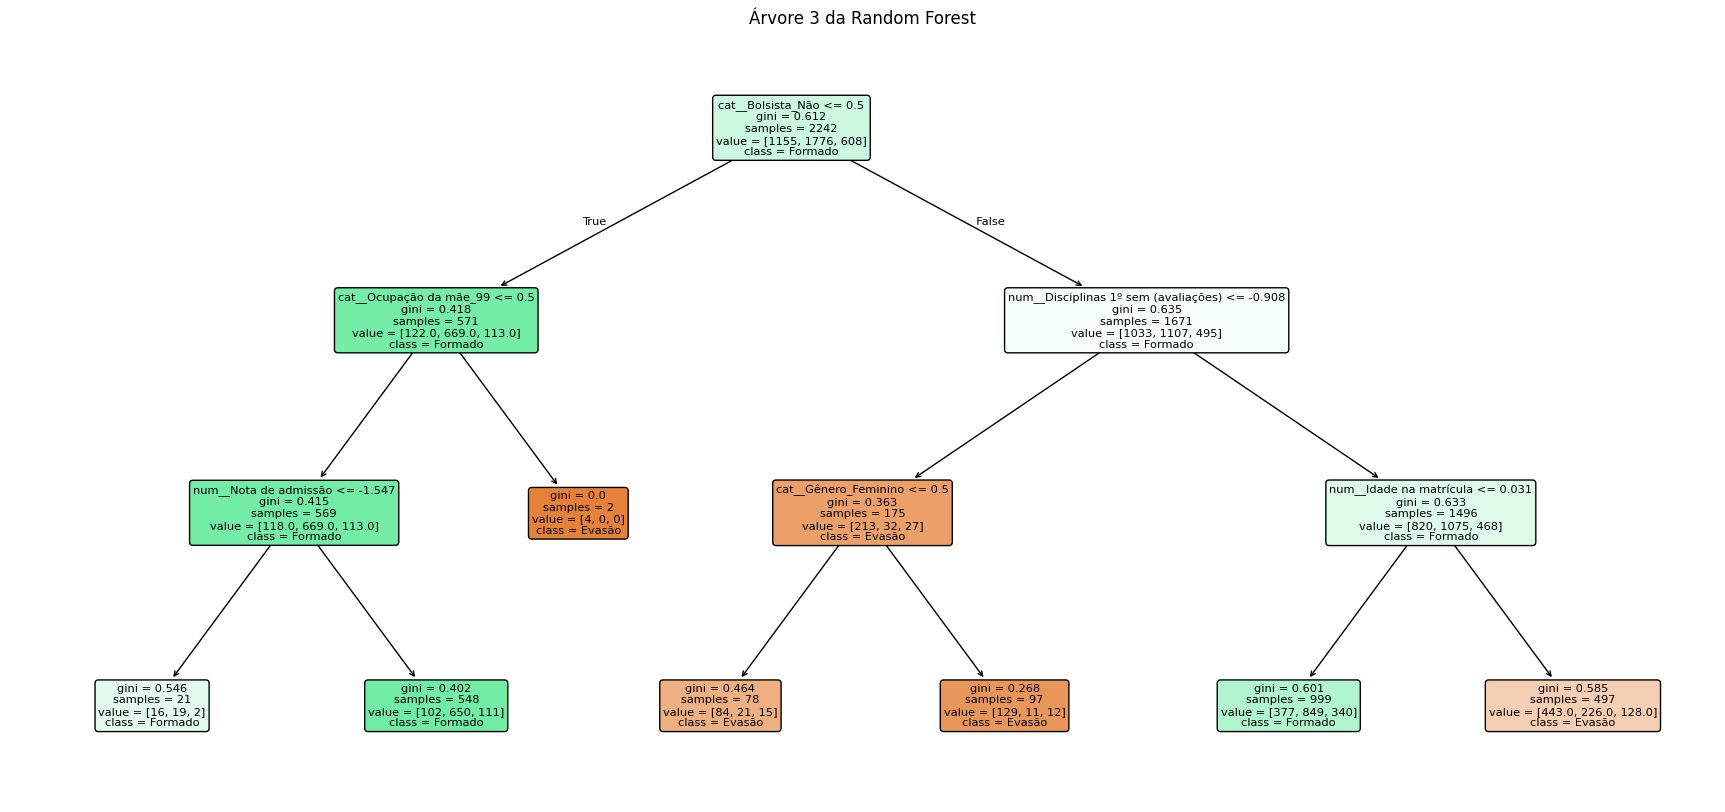

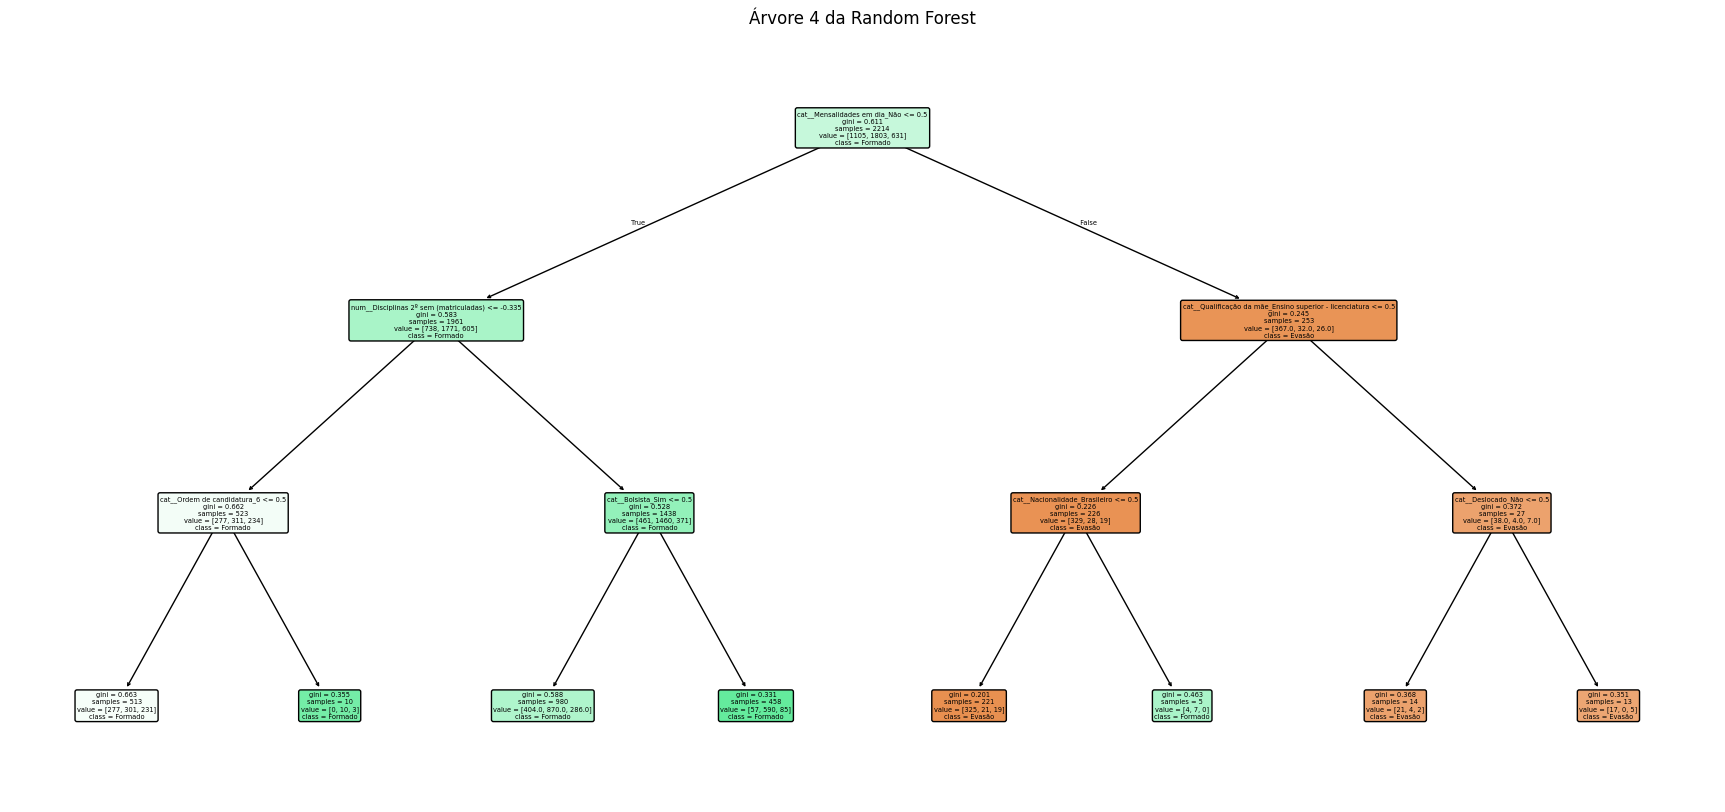

In [ ]:
pipeline = Pipeline([
    ("preprocessamento", preprocessor),
    ("modelo", RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42))
])

pipeline.fit(X_train, y_train)

feature_names = pipeline.named_steps["preprocessamento"].get_feature_names_out()
class_names = [str(c) for c in pipeline.named_steps["modelo"].classes_]

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

for i in range(0,5):
  # pegar uma árvore da floresta
  arvore_rf = pipeline.named_steps["modelo"].estimators_[i]

  plt.figure(figsize=(22,10))

  plot_tree(
      arvore_rf,
      feature_names=feature_names,
      class_names=class_names,
      filled=True,
      rounded=True
  )

  plt.title(f"Árvore {i} da Random Forest")
  plt.show()

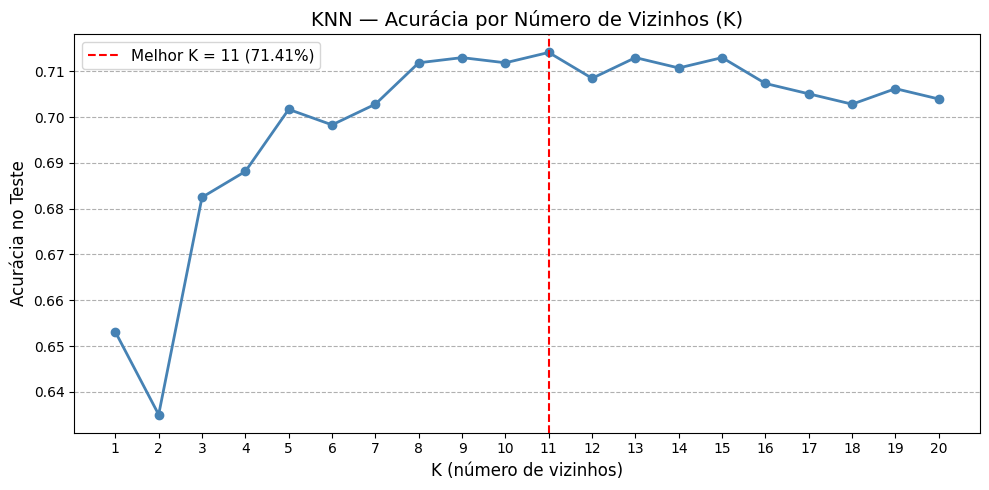

Melhor K encontrado: 11
Acurácia com melhor K: 71.41%
KNN treinado com sucesso! K = 11


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Carregando a base de dados
df = pd.read_csv('data.csv', sep=';')

# 2. Separando features (X) e a variável alvo (y)
X = df.drop('Target', axis=1)
y = df['Target']

# 3. Dividindo em dados de treino e teste (usando 80% para treino e 20% para teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Normalização (Escalonamento)
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train)   # aprende + transforma no treino
X_test_knn  = scaler.transform(X_test)        # apenas transforma no teste

# 5. Buscando o melhor valor para K
acuracias_k = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)
    acuracia = accuracy_score(y_test, knn.predict(X_test_knn))
    acuracias_k.append(acuracia)

# 6. Plotando a curva de acurácia por K
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 21), acuracias_k, marker='o', color='steelblue', linewidth=2)

# Destacando o melhor K
melhor_k = acuracias_k.index(max(acuracias_k)) + 1
ax.axvline(x=melhor_k, color='red', linestyle='--',
           label=f'Melhor K = {melhor_k} ({max(acuracias_k)*100:.2f}%)')

ax.set_title('KNN — Acurácia por Número de Vizinhos (K)', fontsize=14)
ax.set_xlabel('K (número de vizinhos)', fontsize=12)
ax.set_ylabel('Acurácia no Teste', fontsize=12)
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=11)
ax.set_xticks(range(1, 21))

plt.tight_layout()
plt.savefig('knn_curva_k.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Melhor K encontrado: {melhor_k}")
print(f"Acurácia com melhor K: {max(acuracias_k)*100:.2f}%")

# 7. Treinando o modelo final com o melhor K
clf_knn = KNeighborsClassifier(
    n_neighbors=melhor_k,
    metric='euclidean',
    weights='uniform'
)

clf_knn.fit(X_train_knn, y_train)
print(f"KNN treinado com sucesso! K = {melhor_k}")